# Hand Gesture Classification Pipeline
### Final Project - Komputer Cerdas Visi (LBE KCV)

**Nama Kelompok:** Argo Ngawi Jesgejes  
**Kelompok:** 6

**Anggota Kelompok:**
1. Fahmi Alfayadh (5054251015)
2. Dimas Maulana Putra (5025251108)
3. Nabil Khairie (5025251066)
4. Marveilleux Putra Mahasura (5025251109)

Notebook ini mencakup alur lengkap pelatihan model klasifikasi gestur tangan menggunakan **Traditional Machine Learning**:
1. **Feature Extraction:** Ekstraksi 21 koordinat sendi tangan via **MediaPipe Hands**.
2. **Feature Normalization:** Translasi terhadap *wrist* (titik 0) dan penskalaan terhadap ukuran telapak tangan agar invarian posisi dan jarak kamera.
3. **Data Collection:** Perekaman data koordinat langsung dari webcam ke file `dataset_gestures.csv`.
4. **Model Training & Benchmark:** Melatih dan membandingkan 3 model:
   - **Decision Tree**
   - **K-Nearest Neighbors (KNN)**
   - **Logistic Regression**
5. **Evaluation:** Evaluasi metrik (Akurasi, Precision, Recall, F1-Score) dan visualisasi **Confusion Matrix**.
6. **Model Export:** Menyimpan model terbaik ke file `.joblib` untuk inferensi real-time.

## 1. Import Dependensi

In [1]:
import os
import math
import time
import cv2
import joblib
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

# Pemetaan Label Kelas Gestur
CLASS_MAP = {
    0: "STANDBY",
    1: "MOVE",
    2: "SCROLL",
    3: "LEFT_CLICK",
    4: "RIGHT_CLICK"
}

CSV_FILE = "dataset_gestures.csv"
print("Semua pustaka berhasil diimpor!")

Semua pustaka berhasil diimpor!


## 2. Normalisasi Fitur Koordinat

Setiap frame tangan menghasilkan 21 titik koordinat. Dua tahap normalisasi geometris:
1. **Translasi:** Koordinat titik 0 (*wrist*) dijadikan titik asal $(0, 0)$. Semua titik dikurangi koordinat titik 0.
2. **Penskalaan:** Semua jarak dinormalisasi dengan membaginya terhadap jarak antara titik 0 (*wrist*) dan titik 9 (*middle finger MCP*).

In [2]:
def extract_features(landmarks):
    """
    Mengekstrak dan menormalisasi 21 koordinat landmark menjadi 42 fitur numerik.
    """
    base_x = landmarks[0].x
    base_y = landmarks[0].y

    raw_diffs = []
    for lm in landmarks:
        raw_diffs.append(lm.x - base_x)
        raw_diffs.append(lm.y - base_y)

    palm_size = math.hypot(landmarks[9].x - base_x, landmarks[9].y - base_y)
    if palm_size < 1e-6:
        palm_size = 1.0

    return [val / palm_size for val in raw_diffs]

print("Fungsi extract_features siap digunakan.")

Fungsi extract_features siap digunakan.


## 3. Koleksi Data via Webcam Langsung ke CSV

> **Catatan:** Anda bisa menjalankan cell di bawah ini langsung, ATAU menjalankan script di terminal: `python collect_data.py`.

**Petunjuk:**
- Arahkan tangan ke kamera.
- **Tekan dan tahan** tombol angka di keyboard untuk merekam frame gestur tersebut:
  - `0`: STANDBY (Telapak Tangan Terbuka)
  - `1`: MOVE (Telunjuk)
  - `2`: SCROLL (V-pose/ Telunjuk + Jari Tengah)
  - `3`: LEFT_CLICK (3 jari terbuka)
  - `4`: RIGHT_CLICK (4 jari terbuka)
- Tekan tombol **`q`** pada jendela kamera jika sudah selesai.

In [3]:
def collect_data(csv_path=CSV_FILE):
    mp_hands = mp.solutions.hands
    mp_draw = mp.solutions.drawing_utils
    hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7, model_complexity=0)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Kamera tidak dapat dibuka.")
        return

    if not os.path.exists(csv_path):
        header = ["label"] + [f"f_{i}" for i in range(42)]
        with open(csv_path, "w") as f:
            f.write(",".join(header) + "\n")

    counts = {k: 0 for k in CLASS_MAP.keys()}
    if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
        try:
            df_existing = pd.read_csv(csv_path)
            for k in counts:
                counts[k] = int((df_existing["label"] == k).sum())
        except Exception:
            pass

    print("Membuka kamera... Tahan pose tangan dan TEKAN tombol 0, 1, 2, 3, 4. Tekan 'q' untuk selesai.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        features = None
        if results.multi_hand_landmarks:
            hand_lm = results.multi_hand_landmarks[0]
            mp_draw.draw_landmarks(frame, hand_lm, mp_hands.HAND_CONNECTIONS)
            features = extract_features(hand_lm.landmark)

        # Overlay Teks di Layar Kamera
        cv2.rectangle(frame, (10, 10), (320, 160), (30, 30, 30), -1)
        y_offset = 30
        for k, name in CLASS_MAP.items():
            text = f"Key [{k}] {name:<11}: {counts[k]} data"
            cv2.putText(frame, text, (20, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
            y_offset += 22

        cv2.putText(frame, "Tekan 'q' untuk selesai", (20, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)
        cv2.imshow("Data Collector", frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:
            break
        elif key in [ord(str(i)) for i in CLASS_MAP.keys()]:
            label = int(chr(key))
            if features is not None:
                row = [str(label)] + [f"{v:.6f}" for v in features]
                with open(csv_path, "a") as f:
                    f.write(",".join(row) + "\n")
                counts[label] += 1

    cap.release()
    cv2.destroyAllWindows()
    print("Pengumpulan data selesai. Total sampel yang terkumpul:")
    for k, name in CLASS_MAP.items():
        print(f" - {name}: {counts[k]} data")

# Jalankan pengumpulan data
collect_data()

Membuka kamera... Tahan pose tangan dan TEKAN tombol 0, 1, 2, 3, 4. Tekan 'q' untuk selesai.
Pengumpulan data selesai. Total sampel yang terkumpul:
 - STANDBY: 10000 data
 - MOVE: 10000 data
 - SCROLL: 10006 data
 - LEFT_CLICK: 10000 data
 - RIGHT_CLICK: 10000 data


## 4. Eksplorasi Dataset & Pembagian Data (Train-Test Split)

In [4]:
if not os.path.exists(CSV_FILE) or os.path.getsize(CSV_FILE) < 50:
    raise FileNotFoundError(
        f"File '{CSV_FILE}' belum ada atau masih kosong.\n"
        "Silakan jalankan cell pengumpulan data di atas atau jalankan `python collect_data.py` terlebih dahulu!"
    )

df = pd.read_csv(CSV_FILE)
print(f"Total baris data terkumpul: {len(df)}")
print("\nDistribusi Sampel per Kelas:")
dist_df = df["label"].map(CLASS_MAP).value_counts().reset_index()
dist_df.columns = ["Nama Kelas", "Jumlah Sampel"]
display(dist_df)

# split x, y
X = df.drop(columns=["label"]).values
y = df["label"].values

# Train-Test Split (80% Train, 20% Test, Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nJumlah Data Train: {X_train.shape[0]} sampel")
print(f"Jumlah Data Test : {X_test.shape[0]} sampel")

Total baris data terkumpul: 50006

Distribusi Sampel per Kelas:


,Nama Kelas,Jumlah Sampel
0,SCROLL,10006
1,STANDBY,10000
2,MOVE,10000
3,LEFT_CLICK,10000
4,RIGHT_CLICK,10000



Jumlah Data Train: 40004 sampel
Jumlah Data Test : 10002 sampel


In [5]:
df.head()

,label,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_32,f_33,f_34,f_35,f_36,f_37,f_38,f_39,f_40,f_41
0,0,0.0,0.0,-0.302454,-0.100135,-0.560672,-0.348454,-0.730382,-0.566545,-0.838851,...,0.084765,-1.815100,0.156706,-0.826755,0.286916,-1.095916,0.374535,-1.278417,0.456512,-1.454240
1,0,0.0,0.0,-0.280197,-0.086234,-0.531063,-0.309204,-0.714979,-0.472923,-0.864663,...,0.093172,-1.825223,0.172892,-0.820548,0.309398,-1.081725,0.396897,-1.258273,0.473127,-1.433295
2,0,0.0,0.0,-0.279016,-0.086279,-0.529748,-0.310972,-0.713783,-0.479819,-0.866367,...,0.094384,-1.828283,0.177101,-0.822284,0.313450,-1.088039,0.399516,-1.262095,0.472940,-1.430521
3,0,0.0,0.0,-0.277323,-0.093840,-0.528516,-0.316867,-0.711112,-0.485874,-0.855859,...,0.104828,-1.828777,0.186145,-0.822272,0.327164,-1.087469,0.415507,-1.260877,0.490715,-1.429053
4,0,0.0,0.0,-0.280109,-0.091896,-0.528764,-0.320122,-0.713567,-0.485755,-0.861102,...,0.107555,-1.824756,0.180968,-0.821730,0.327625,-1.081352,0.421388,-1.255667,0.501965,-1.424484


## 5. Training & bandingkan 3 Model 

Melatih dan membandingkan performa 3 algoritma klasifikasi:
1. **Decision Tree Classifier (`max_depth=6`)**
2. **K-Nearest Neighbors (`n_neighbors=5`)**
3. **Logistic Regression (`max_iter=1000`)**

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    start_train = time.time()
    model.fit(X_train, y_train)
    fit_time = (time.time() - start_train) * 1000  # milidetik

    train_acc = accuracy_score(y_train, model.predict(X_train))
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    trained_models[name] = model
    results.append({
        "Model": name,
        "Train Accuracy": f"{train_acc * 100:.2f}%",
        "Test Accuracy": f"{test_acc * 100:.2f}%",
        "Fit Time (ms)": f"{fit_time:.2f} ms"
    })

# Tampilkan Tabel Perbandingan Faktual
res_df = pd.DataFrame(results)
print("Tabel Komparasi Performa Model:")
display(res_df)

# Classification Report Lengkap untuk masing-masing model
present_classes = sorted(np.unique(y_test))
target_names = [CLASS_MAP[i] for i in present_classes]
for name, model in trained_models.items():
    print(f"\n{'=' * 50}")
    print(f"Classification Report: {name}")
    print('=' * 50)
    print(classification_report(y_test, model.predict(X_test), labels=present_classes, target_names=target_names))

Tabel Komparasi Performa Model:


,Model,Train Accuracy,Test Accuracy,Fit Time (ms)
0,Decision Tree,98.12%,97.77%,657.62 ms
1,K-Nearest Neighbors,99.88%,99.84%,1.00 ms
2,Logistic Regression,98.78%,98.67%,1792.23 ms



Classification Report: Decision Tree
              precision    recall  f1-score   support

     STANDBY       0.98      0.98      0.98      2000
        MOVE       0.99      0.99      0.99      2000
      SCROLL       0.97      0.99      0.98      2002
  LEFT_CLICK       0.98      0.97      0.97      2000
 RIGHT_CLICK       0.97      0.96      0.96      2000

    accuracy                           0.98     10002
   macro avg       0.98      0.98      0.98     10002
weighted avg       0.98      0.98      0.98     10002


Classification Report: K-Nearest Neighbors
              precision    recall  f1-score   support

     STANDBY       1.00      1.00      1.00      2000
        MOVE       1.00      1.00      1.00      2000
      SCROLL       1.00      1.00      1.00      2002
  LEFT_CLICK       1.00      1.00      1.00      2000
 RIGHT_CLICK       1.00      1.00      1.00      2000

    accuracy                           1.00     10002
   macro avg       1.00      1.00      1.00     1

## 6. Visualisasi Confusion Matrix

Memeriksa pola kesalahan prediksi (*confusion matrix*) dari masing-masing model secara visual.

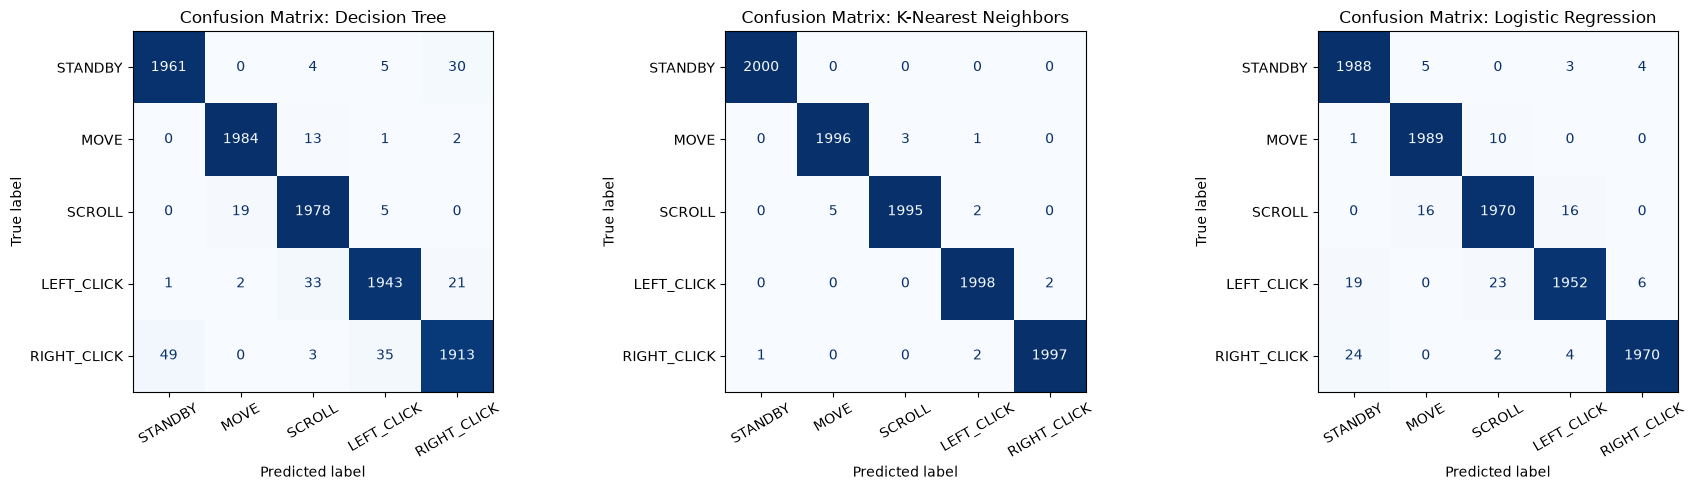

In [7]:
present_classes = sorted(np.unique(y_test))
target_names = [CLASS_MAP[i] for i in present_classes]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        labels=present_classes,
        display_labels=target_names,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"Confusion Matrix: {name}")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Ekspor Model Terbaik ke File

Pilih model dengan akurasi data test tertinggi dan simpan ke file `.joblib` agar dapat langsung di-*load* oleh kontroler real-time.

In [8]:
best_model_name = max(trained_models.keys(), key=lambda m: accuracy_score(y_test, trained_models[m].predict(X_test)))
best_model = trained_models[best_model_name]
best_acc = accuracy_score(y_test, best_model.predict(X_test))

MODEL_FILE = "best_gesture_model.joblib"
joblib.dump({
    "model": best_model,
    "model_name": best_model_name,
    "class_map": CLASS_MAP
}, MODEL_FILE)

print(f"Model terbaik: {best_model_name} (Akurasi: {best_acc * 100:.2f}%)")
print(f"Model berhasil disimpan ke: {MODEL_FILE}")

Model terbaik: K-Nearest Neighbors (Akurasi: 99.84%)
Model berhasil disimpan ke: best_gesture_model.joblib
